In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
# import torch
# torch.cuda.empty_cache()

In [2]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/home/stud/ath/ath_ws/keypoint_dataset_pipeline/output/output_all_missing/train/train_data.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
dl = dm.train_dataloader()

In [ ]:
batch = next(iter(dl))

reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

torch.Size([175, 1, 32, 32]) torch.Size([175, 1, 32, 32])
torch.Size([175, 2]) torch.Size([175, 2])


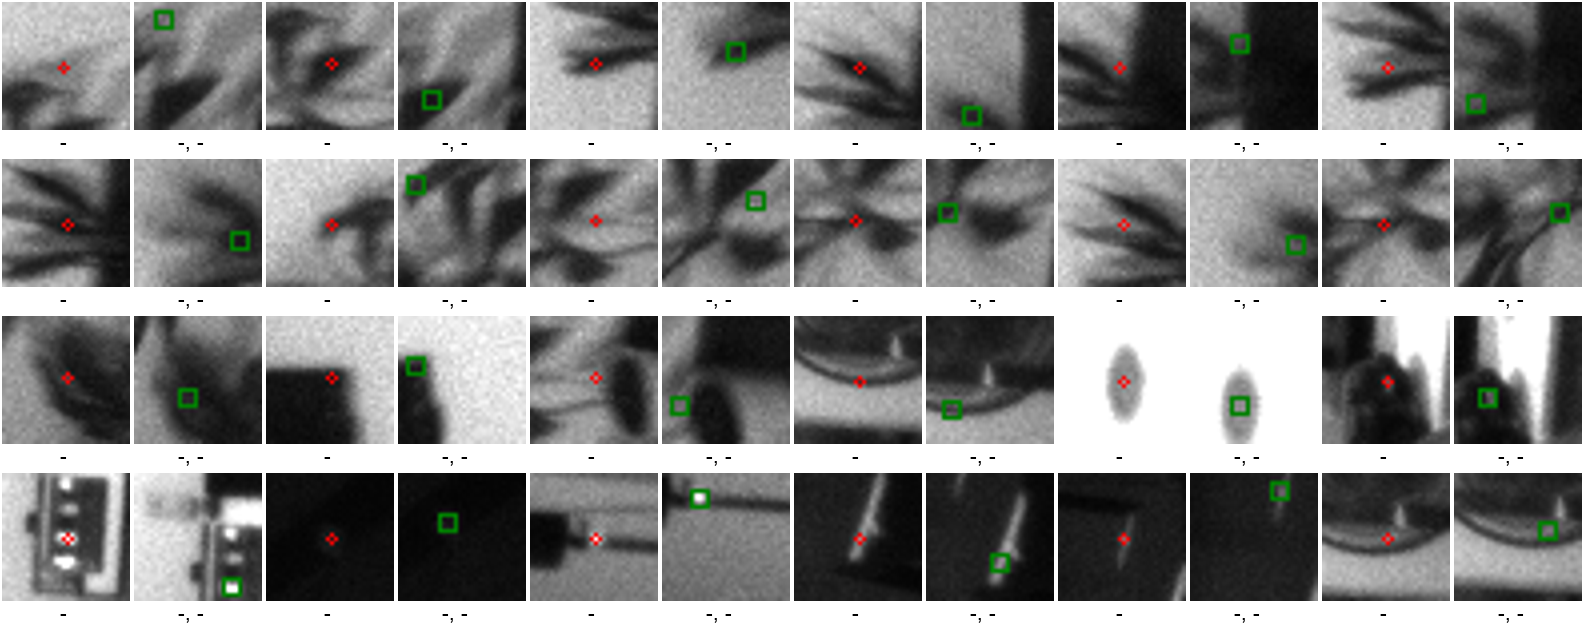

In [ ]:
# batch = next(iter(dl))

# reference_patches = batch.reference_patches
# target_patches = batch.target_patches
# print(reference_patches.shape, target_patches.shape) 

# patch_level_reference_coords = batch.patch_level_reference_coords
# patch_level_target_coords = batch.patch_level_target_coords
# print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

count = 24 * 1

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    # rotations_true=batch.rotations,
    # rotations=batch.rotations,
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

# Rotation Interpretation
# How to get reference patch using target patch?
# Positive = Anti-clockwise movement
# Negative = Clockwise movement

In [ ]:
config.image.patch_border

6

In [ ]:
# print("Texture Features (Contrast, Energy, Entropy, Homogeneity):")
# print(texture_features[:count])

In [ ]:
# print(patch_level_target_coords.shape)

# pred = torch.rand(90, 2) * 2 - 1
# print(pred.shape)

# target = patch_level_target_coords

# # Scale pred from [-1, 1] to [0, 31]
# scaled_pred = (pred.float() + 1) * 15.5 
# print(scaled_pred.shape)

# difference = torch.abs(target - target)
# print(difference.shape)

# # Check which differences exceed N pixels
# exceeds = (difference > 1).any(dim=1)
# print(exceeds.shape)

# # Calculate the percentage
# percentage = (exceeds.sum().item() / scaled_pred.shape[0]) * 100
# print(percentage)

In [ ]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

# Check Model

In [ ]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [ ]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

4,956,802


In [ ]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

# target_coords, target_confidence, target_rotation = light(
#     reference_patches, 
#     target_patches, 
#     patch_level_reference_coords
# )

# target_coords, target_confidence = light(
#     reference_patches, 
#     target_patches, 
#     patch_level_reference_coords
# )

target_coords = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
# print(f'target_confidence shape : {target_confidence.shape}')
# print(f'target_rotation shape : {target_rotation.shape}')

Model Inputs
reference_patches shape : torch.Size([175, 1, 32, 32])
target_patches shape : torch.Size([175, 1, 32, 32])
patch_level_reference_coords shape : torch.Size([175, 2])
Model Outputs
target_coords shape : torch.Size([175, 2])


In [ ]:
# from torchinfo import summary

# summary(
#     light.model, 
#     input_data=[
#         reference_patches, 
#         target_patches, 
#         patch_level_reference_coords
#     ]
# )